# ODIR Dataset — Preprocessing Visualization
Charts covering dataset statistics, demographics, label distribution, image transforms, and pixel analysis.

In [1]:
import os
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap
import torchvision.transforms as transforms
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11

In [2]:
DATA_PATH   = 'odir-data/data.xlsx'
IMAGE_DIR   = 'odir-data/crop_training_images'
IMAGE_SIZE  = 128
TARGET_COLS = ['N', 'D', 'G', 'C', 'A', 'H', 'M', 'O']
LABEL_NAMES = {
    'N': 'Normal',
    'D': 'Diabetic Retinopathy',
    'G': 'Glaucoma',
    'C': 'Cataract',
    'A': 'Age-related Macular\nDegeneration (AMD)',
    'H': 'Hypertension',
    'M': 'Myopia',
    'O': 'Other'
}
COLORS = ['#4C72B0','#DD8452','#55A868','#C44E52','#8172B2','#937860','#DA8BC3','#8C8C8C']

In [3]:
df = pd.read_excel(DATA_PATH)
print(f"Dataset shape : {df.shape}")
print(f"Columns       : {df.columns.tolist()}")
df.head()

Dataset shape : (3500, 15)
Columns       : ['ID', 'Patient Age', 'Patient Sex', 'Left-Fundus', 'Right-Fundus', 'Left-Diagnostic Keywords', 'Right-Diagnostic Keywords', 'N', 'D', 'G', 'C', 'A', 'H', 'M', 'O']


,ID,Patient Age,Patient Sex,Left-Fundus,Right-Fundus,Left-Diagnostic Keywords,Right-Diagnostic Keywords,N,D,G,C,A,H,M,O
0,0,69,Female,0_left.jpg,0_right.jpg,cataract,normal fundus,0,0,0,1,0,0,0,0
1,1,57,Male,1_left.jpg,1_right.jpg,normal fundus,normal fundus,1,0,0,0,0,0,0,0
2,2,42,Male,2_left.jpg,2_right.jpg,laser spot，moderate non proliferative retinopathy,moderate non proliferative retinopathy,0,1,0,0,0,0,0,1
3,3,66,Male,3_left.jpg,3_right.jpg,normal fundus,branch retinal artery occlusion,0,0,0,0,0,0,0,1
4,4,53,Male,4_left.jpg,4_right.jpg,macular epiretinal membrane,mild nonproliferative retinopathy,0,1,0,0,0,0,0,1


---
## 1. Label Distribution

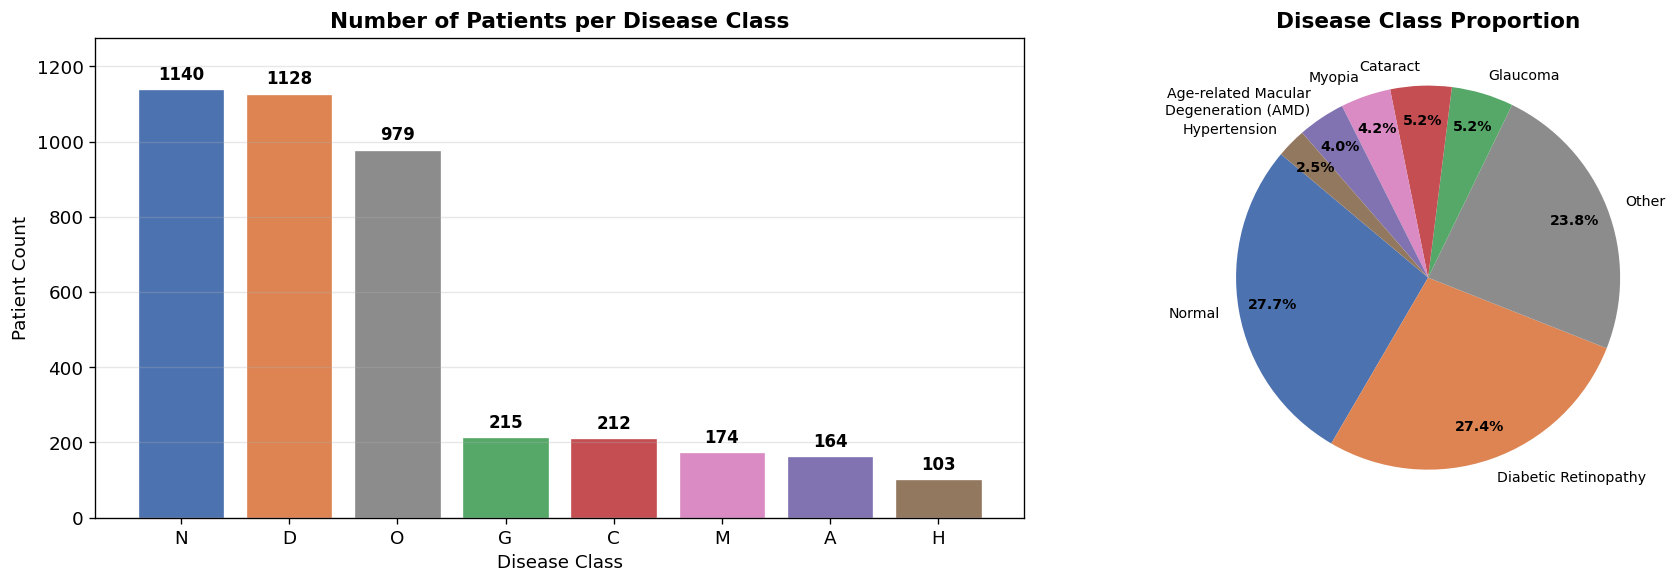

In [4]:
label_counts = df[TARGET_COLS].sum().sort_values(ascending=False)
short_names  = [c for c in label_counts.index]
long_names   = [LABEL_NAMES[c] for c in short_names]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Bar chart
bars = axes[0].bar(short_names, label_counts.values,
                   color=[COLORS[TARGET_COLS.index(c)] for c in short_names],
                   edgecolor='white', linewidth=0.8)
for bar, val in zip(bars, label_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 15,
                 str(int(val)), ha='center', va='bottom', fontsize=10, fontweight='bold')
axes[0].set_title('Number of Patients per Disease Class', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Disease Class')
axes[0].set_ylabel('Patient Count')
axes[0].grid(axis='y', alpha=0.3)
axes[0].set_ylim(0, label_counts.max() * 1.12)

# Pie chart
wedge_colors = [COLORS[TARGET_COLS.index(c)] for c in short_names]
wedges, texts, autotexts = axes[1].pie(
    label_counts.values, labels=long_names, colors=wedge_colors,
    autopct='%1.1f%%', startangle=140,
    pctdistance=0.82, textprops={'fontsize': 8.5}
)
for at in autotexts:
    at.set_fontweight('bold')
axes[1].set_title('Disease Class Proportion', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('chart_label_distribution.png', bbox_inches='tight')
plt.show()

---
## 2. Patient Demographics

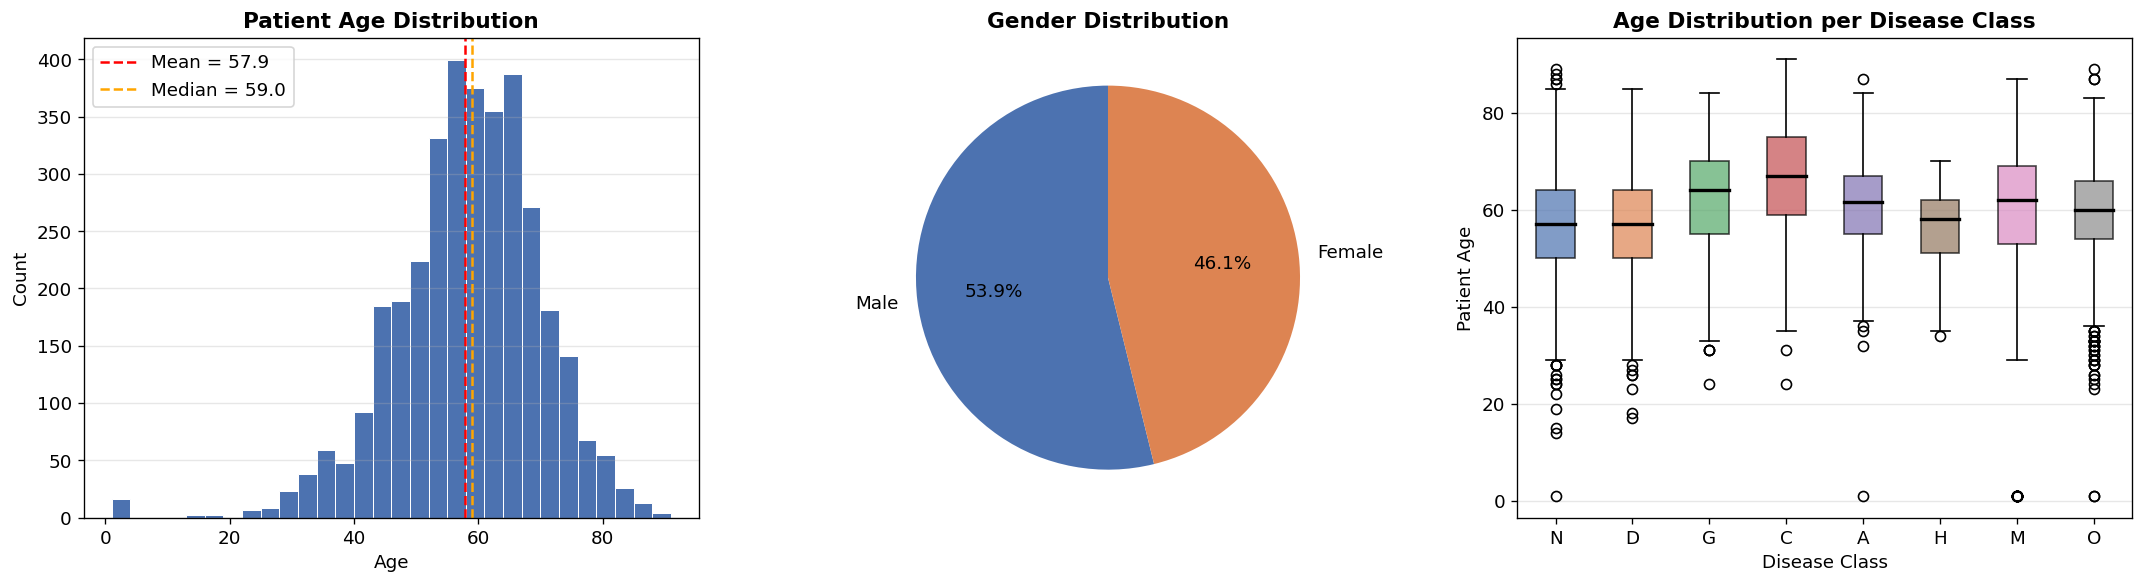

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Age histogram
axes[0].hist(df['Patient Age'], bins=30, color='#4C72B0', edgecolor='white', linewidth=0.6)
axes[0].axvline(df['Patient Age'].mean(), color='red', linestyle='--', linewidth=1.5,
                label=f"Mean = {df['Patient Age'].mean():.1f}")
axes[0].axvline(df['Patient Age'].median(), color='orange', linestyle='--', linewidth=1.5,
                label=f"Median = {df['Patient Age'].median():.1f}")
axes[0].set_title('Patient Age Distribution', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Count')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# Gender pie
gender_counts = df['Patient Sex'].value_counts()
axes[1].pie(gender_counts.values, labels=gender_counts.index,
            colors=['#4C72B0','#DD8452'],
            autopct='%1.1f%%', startangle=90,
            textprops={'fontsize': 11})
axes[1].set_title('Gender Distribution', fontsize=13, fontweight='bold')

# Age box per disease
age_per_class = [df[df[col] == 1]['Patient Age'].dropna().values for col in TARGET_COLS]
bp = axes[2].boxplot(age_per_class, patch_artist=True,
                     medianprops=dict(color='black', linewidth=2))
for patch, color in zip(bp['boxes'], COLORS):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[2].set_xticks(range(1, len(TARGET_COLS)+1))
axes[2].set_xticklabels(TARGET_COLS)
axes[2].set_title('Age Distribution per Disease Class', fontsize=13, fontweight='bold')
axes[2].set_xlabel('Disease Class')
axes[2].set_ylabel('Patient Age')
axes[2].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('chart_demographics.png', bbox_inches='tight')
plt.show()

---
## 3. Multi-label Statistics

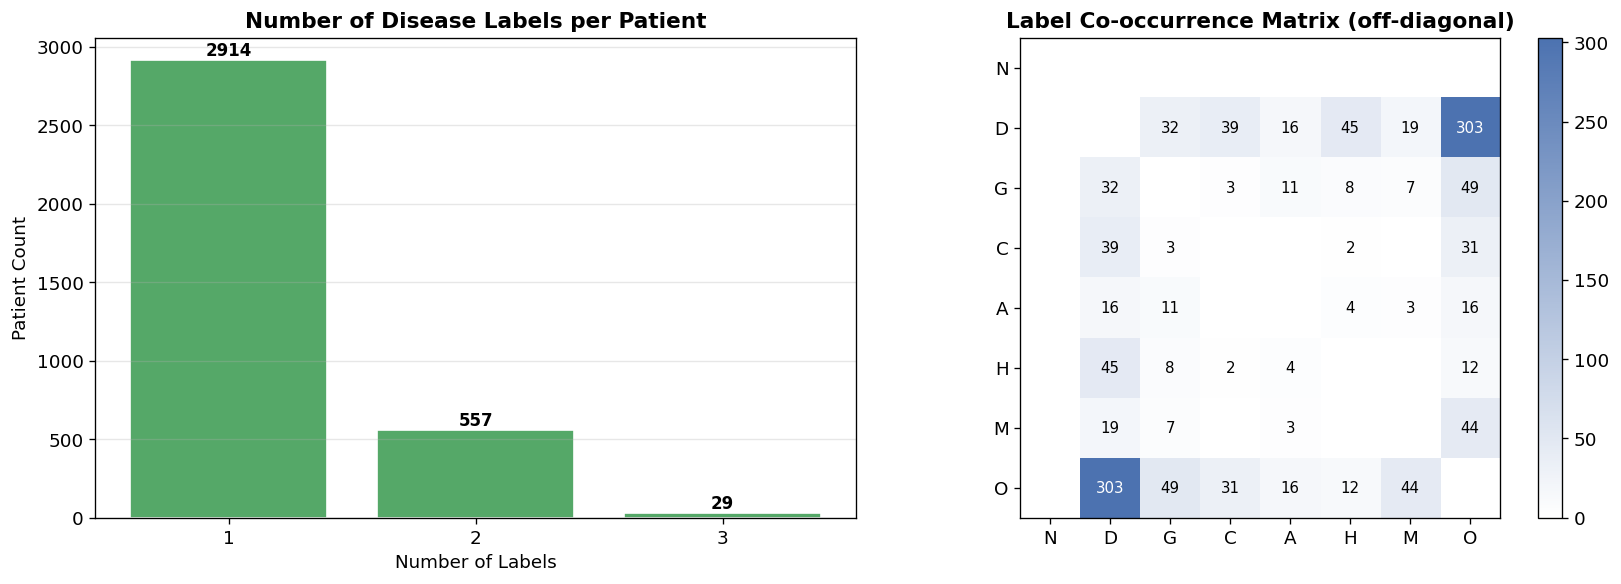

In [6]:
df['label_count'] = df[TARGET_COLS].sum(axis=1)
label_count_dist  = df['label_count'].value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Labels per patient
bars = axes[0].bar(label_count_dist.index.astype(str), label_count_dist.values,
                   color='#55A868', edgecolor='white')
for bar, val in zip(bars, label_count_dist.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                 str(val), ha='center', va='bottom', fontsize=10, fontweight='bold')
axes[0].set_title('Number of Disease Labels per Patient', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Number of Labels')
axes[0].set_ylabel('Patient Count')
axes[0].grid(axis='y', alpha=0.3)

# Label co-occurrence heatmap
co_matrix = df[TARGET_COLS].T.dot(df[TARGET_COLS])
np.fill_diagonal(co_matrix.values, 0)   # zero diagonal for clearer off-diag

cmap = LinearSegmentedColormap.from_list('odir', ['#ffffff','#4C72B0'])
im = axes[1].imshow(co_matrix.values, cmap=cmap)
axes[1].set_xticks(range(len(TARGET_COLS)))
axes[1].set_yticks(range(len(TARGET_COLS)))
axes[1].set_xticklabels(TARGET_COLS)
axes[1].set_yticklabels(TARGET_COLS)
axes[1].set_title('Label Co-occurrence Matrix (off-diagonal)', fontsize=13, fontweight='bold')
plt.colorbar(im, ax=axes[1])
for i in range(len(TARGET_COLS)):
    for j in range(len(TARGET_COLS)):
        val = co_matrix.values[i, j]
        if val > 0:
            axes[1].text(j, i, str(int(val)), ha='center', va='center',
                         fontsize=9, color='white' if val > co_matrix.values.max()*0.5 else 'black')

plt.tight_layout()
plt.savefig('chart_multilabel.png', bbox_inches='tight')
plt.show()

---
## 4. Data Split (70 / 20 / 10)

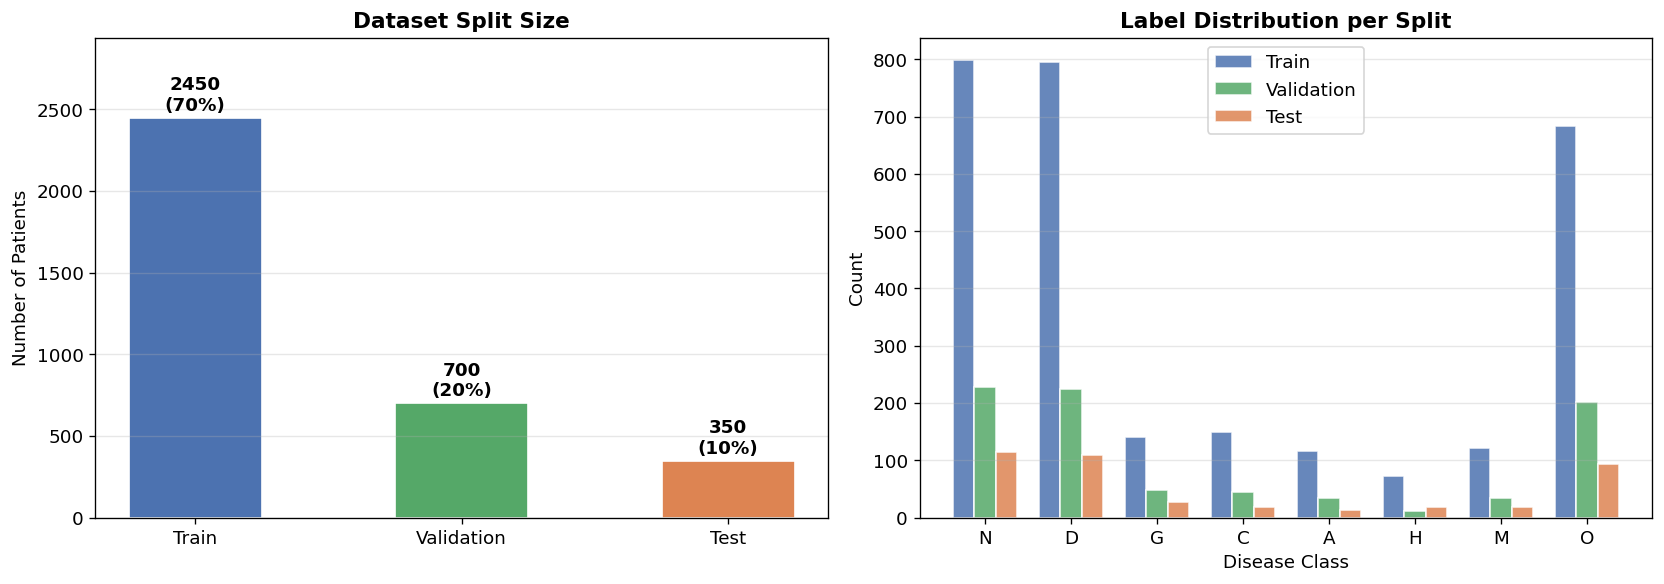

Train: 2450 | Val: 700 | Test: 350


In [7]:
from sklearn.model_selection import train_test_split

train_df, temp_df = train_test_split(df, test_size=0.3, random_state=42,
                                     stratify=df['N'])
val_df, test_df   = train_test_split(temp_df, test_size=0.333, random_state=42,
                                     stratify=temp_df['N'])

split_sizes = [len(train_df), len(val_df), len(test_df)]
split_names = ['Train', 'Validation', 'Test']
split_colors= ['#4C72B0', '#55A868', '#DD8452']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar
bars = axes[0].bar(split_names, split_sizes, color=split_colors, edgecolor='white', width=0.5)
for bar, val in zip(bars, split_sizes):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
                 f"{val}\n({val/len(df)*100:.0f}%)",
                 ha='center', va='bottom', fontsize=11, fontweight='bold')
axes[0].set_title('Dataset Split Size', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Number of Patients')
axes[0].set_ylim(0, max(split_sizes)*1.2)
axes[0].grid(axis='y', alpha=0.3)

# Class balance per split
x = np.arange(len(TARGET_COLS))
w = 0.25
for i, (split, sdf, color) in enumerate(zip(split_names, [train_df, val_df, test_df], split_colors)):
    counts = sdf[TARGET_COLS].sum().values
    axes[1].bar(x + i*w, counts, w, label=split, color=color, alpha=0.85, edgecolor='white')
axes[1].set_title('Label Distribution per Split', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Disease Class')
axes[1].set_ylabel('Count')
axes[1].set_xticks(x + w)
axes[1].set_xticklabels(TARGET_COLS)
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('chart_split.png', bbox_inches='tight')
plt.show()
print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")

---
## 5. Sample Images per Class

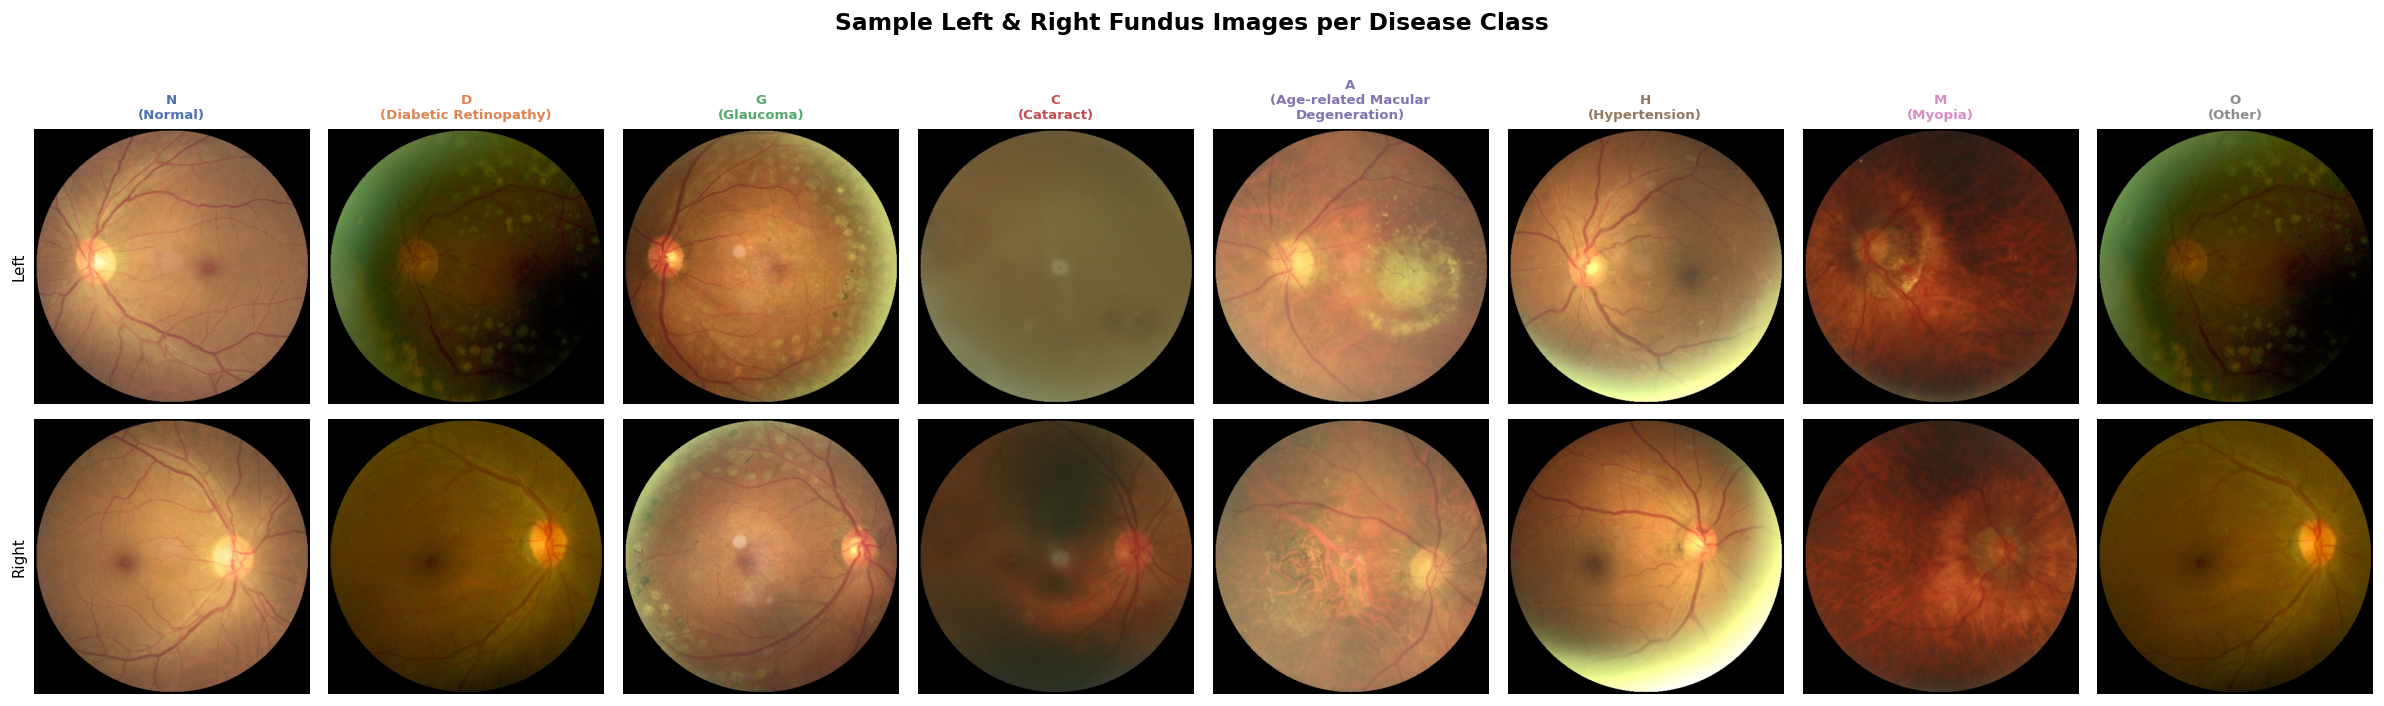

In [8]:
fig, axes = plt.subplots(2, 8, figsize=(20, 6))
fig.suptitle('Sample Left & Right Fundus Images per Disease Class', fontsize=14, fontweight='bold', y=1.01)

for col_idx, cls in enumerate(TARGET_COLS):
    sample = df[df[cls] == 1].iloc[0]
    sid    = sample['ID']
    
    for row_idx, side in enumerate(['left', 'right']):
        img_path = os.path.join(IMAGE_DIR, f"{sid}_{side}.jpg")
        img      = Image.open(img_path).convert('RGB')
        ax       = axes[row_idx][col_idx]
        ax.imshow(img)
        ax.axis('off')
        if row_idx == 0:
            short = cls
            ax.set_title(f"{short}\n({LABEL_NAMES[cls].split('(')[0].strip()})",
                         fontsize=8, fontweight='bold', color=COLORS[col_idx])
        if col_idx == 0:
            ax.set_ylabel(side.capitalize(), fontsize=9)
            ax.axis('on')
            ax.set_yticks([])
            ax.set_xticks([])
            for spine in ax.spines.values():
                spine.set_visible(False)

plt.tight_layout()
plt.savefig('chart_sample_images.png', bbox_inches='tight')
plt.show()

---
## 6. Preprocessing Pipeline Visualization

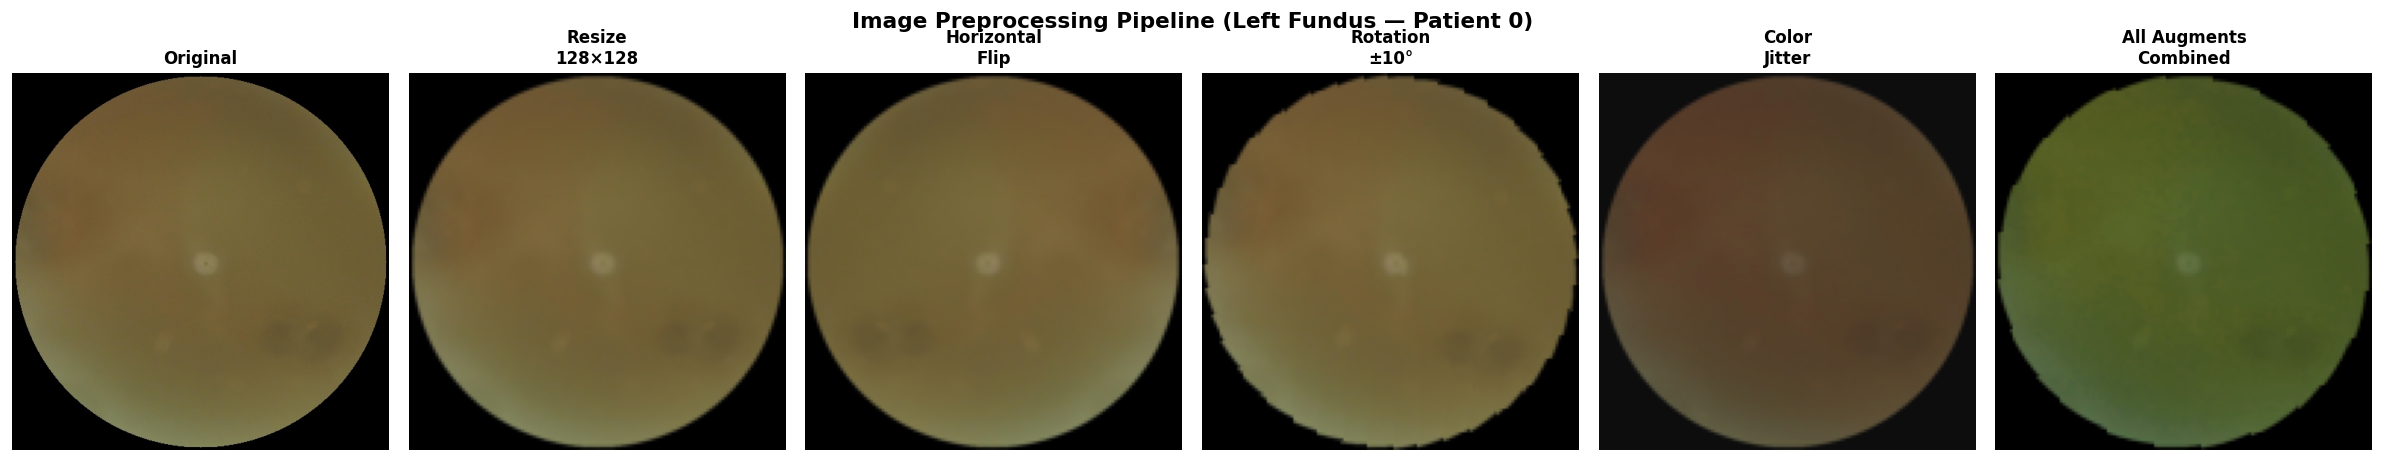

In [9]:
# Pick one sample image
sample_id   = df.iloc[0]['ID']
sample_path = os.path.join(IMAGE_DIR, f"{sample_id}_left.jpg")
orig_img    = Image.open(sample_path).convert('RGB')

# Define step-by-step transforms to visualize
steps = [
    ('Original', None),
    ('Resize\n128×128', transforms.Resize((IMAGE_SIZE, IMAGE_SIZE))),
    ('Horizontal\nFlip', transforms.Compose([
        transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
        transforms.RandomHorizontalFlip(p=1.0)
    ])),
    ('Rotation\n±10°', transforms.Compose([
        transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
        transforms.RandomRotation(10)
    ])),
    ('Color\nJitter', transforms.Compose([
        transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
        transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.1)
    ])),
    ('All Augments\nCombined', transforms.Compose([
        transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomRotation(10),
        transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1)
    ])),
]

fig, axes = plt.subplots(1, len(steps), figsize=(20, 4))
fig.suptitle('Image Preprocessing Pipeline (Left Fundus — Patient 0)',
             fontsize=13, fontweight='bold')

for ax, (title, tf) in zip(axes, steps):
    img = orig_img if tf is None else tf(orig_img)
    ax.imshow(img)
    ax.set_title(title, fontsize=10, fontweight='bold')
    ax.axis('off')

plt.tight_layout()
plt.savefig('chart_preprocess_pipeline.png', bbox_inches='tight')
plt.show()

---
## 7. Normalized Image vs. Original (Tensor Visualization)

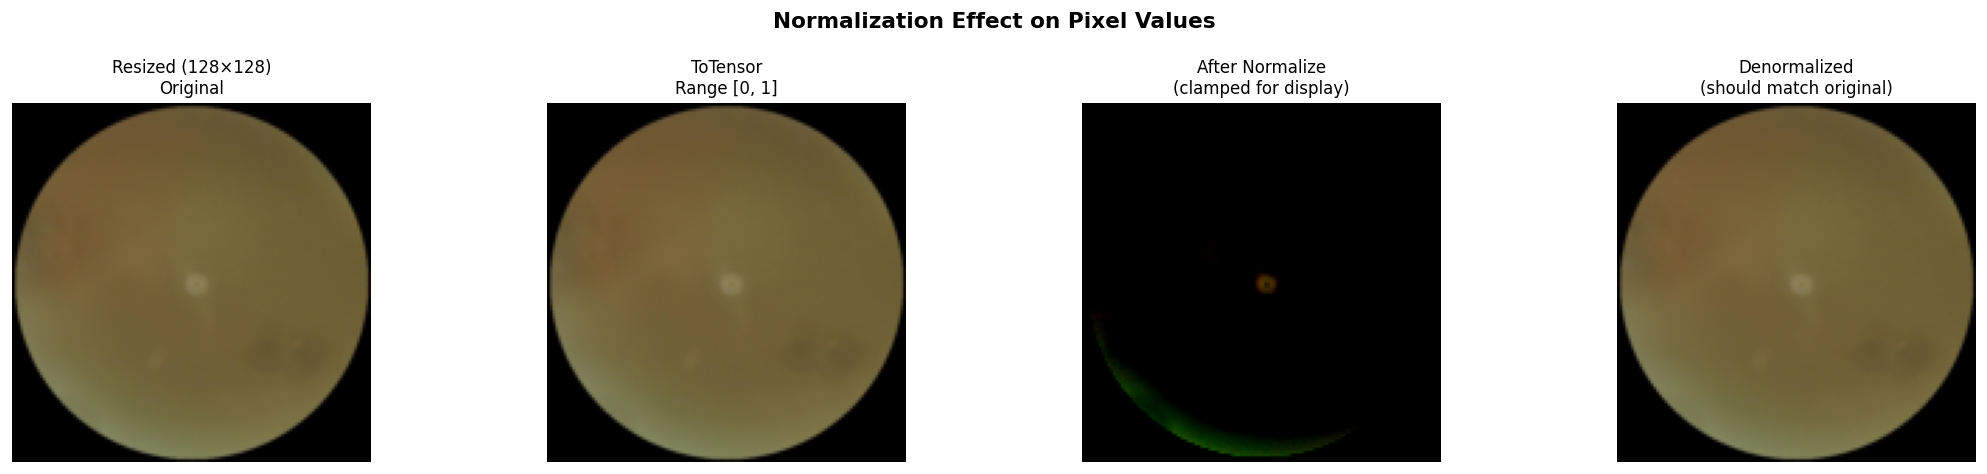

In [10]:
import torch

to_tensor    = transforms.ToTensor()
normalize    = transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                    std =[0.229, 0.224, 0.225])
resize_tf    = transforms.Resize((IMAGE_SIZE, IMAGE_SIZE))

img_resized  = resize_tf(orig_img)
tensor       = to_tensor(img_resized)          # [0,1]
tensor_norm  = normalize(tensor.clone())       # normalized

def tensor_to_displayable(t):
    """Clip and convert tensor to numpy for imshow."""
    arr = t.permute(1, 2, 0).numpy()
    return np.clip(arr, 0, 1)

def tensor_to_denorm(t):
    """Denormalize ImageNet-normalized tensor back to [0,1]."""
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
    std  = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)
    return torch.clamp(t * std + mean, 0, 1)

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
fig.suptitle('Normalization Effect on Pixel Values', fontsize=13, fontweight='bold')

# Original
axes[0].imshow(img_resized)
axes[0].set_title('Resized (128×128)\nOriginal', fontsize=10)
axes[0].axis('off')

# Tensor [0,1]
axes[1].imshow(tensor_to_displayable(tensor))
axes[1].set_title('ToTensor\nRange [0, 1]', fontsize=10)
axes[1].axis('off')

# Normalized (clamped for display)
axes[2].imshow(tensor_to_displayable(tensor_norm))
axes[2].set_title('After Normalize\n(clamped for display)', fontsize=10)
axes[2].axis('off')

# Denormalized — should match original
axes[3].imshow(tensor_to_displayable(tensor_to_denorm(tensor_norm)))
axes[3].set_title('Denormalized\n(should match original)', fontsize=10)
axes[3].axis('off')

plt.tight_layout()
plt.savefig('chart_normalization.png', bbox_inches='tight')
plt.show()

---
## 8. Pixel Intensity & RGB Channel Statistics

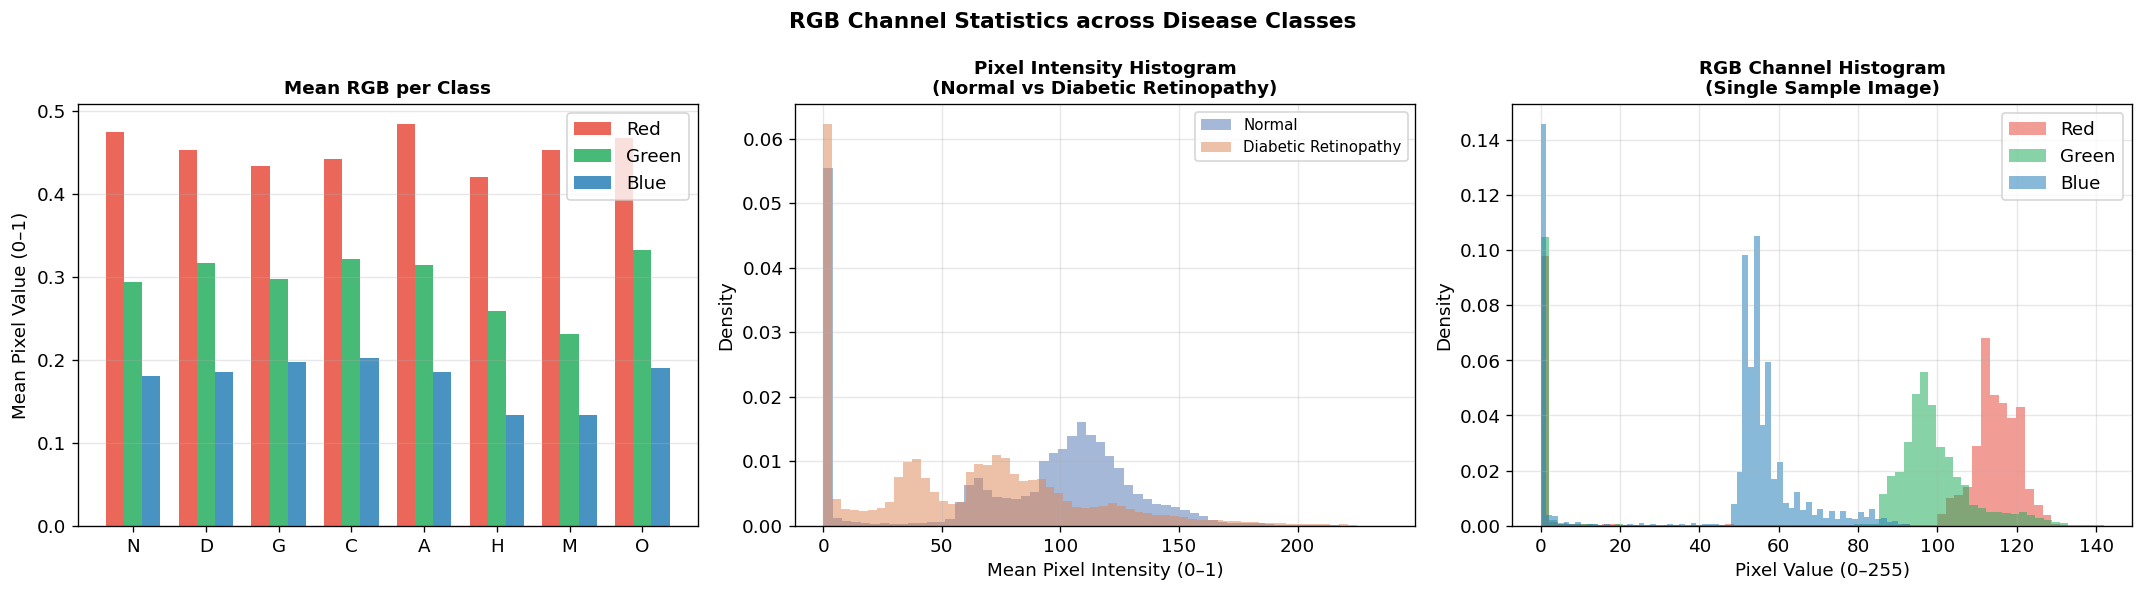

In [11]:
# Sample up to 5 images per class for efficiency
SAMPLE_PER_CLASS = 5

channel_means = {cls: [] for cls in TARGET_COLS}  # each entry: (R_mean, G_mean, B_mean)

resize_fn = transforms.Resize((IMAGE_SIZE, IMAGE_SIZE))

for cls in TARGET_COLS:
    samples = df[df[cls] == 1].head(SAMPLE_PER_CLASS)
    for _, row in samples.iterrows():
        sid      = row['ID']
        for side in ['left', 'right']:
            path = os.path.join(IMAGE_DIR, f"{sid}_{side}.jpg")
            img  = resize_fn(Image.open(path).convert('RGB'))
            arr  = np.array(img) / 255.0          # (H, W, 3)
            channel_means[cls].append(arr.mean(axis=(0,1)))   # (R,G,B)

# Compute per-class means
cls_rgb = {cls: np.array(vals).mean(axis=0) for cls, vals in channel_means.items()}

# Pixel intensity distribution for one class (Normal vs Diabetic)
def get_pixel_array(cls, side='left', n=3):
    rows   = df[df[cls] == 1].head(n)
    arrays = []
    for _, row in rows.iterrows():
        path = os.path.join(IMAGE_DIR, f"{row['ID']}_{side}.jpg")
        img  = resize_fn(Image.open(path).convert('RGB'))
        arrays.append(np.array(img).reshape(-1, 3))
    return np.vstack(arrays)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('RGB Channel Statistics across Disease Classes', fontsize=13, fontweight='bold')

# Grouped bar: mean R, G, B per class
x = np.arange(len(TARGET_COLS))
w = 0.25
ch_colors = ['#e74c3c', '#27ae60', '#2980b9']
for i, (ch, ch_name) in enumerate(zip([0,1,2], ['Red','Green','Blue'])):
    vals = [cls_rgb[c][ch] for c in TARGET_COLS]
    axes[0].bar(x + i*w, vals, w, label=ch_name, color=ch_colors[i], alpha=0.85)
axes[0].set_xticks(x + w)
axes[0].set_xticklabels(TARGET_COLS)
axes[0].set_title('Mean RGB per Class', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Mean Pixel Value (0–1)')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# Histogram: pixel intensity — Normal vs Diabetic
for cls, color, ls in [('N','#4C72B0','-'), ('D','#DD8452','--')]:
    pixels = get_pixel_array(cls)
    axes[1].hist(pixels.mean(axis=1), bins=60, alpha=0.5, color=color,
                 label=LABEL_NAMES[cls].split('(')[0].strip(), density=True, linestyle=ls)
axes[1].set_title('Pixel Intensity Histogram\n(Normal vs Diabetic Retinopathy)', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Mean Pixel Intensity (0–1)')
axes[1].set_ylabel('Density')
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.3)

# RGB channel histogram for one image
sample_img_arr = np.array(resize_fn(orig_img))
for ch, ch_name, color in zip([0,1,2], ['Red','Green','Blue'], ch_colors):
    axes[2].hist(sample_img_arr[:,:,ch].ravel(), bins=64, alpha=0.55,
                 color=color, label=ch_name, density=True)
axes[2].set_title('RGB Channel Histogram\n(Single Sample Image)', fontsize=11, fontweight='bold')
axes[2].set_xlabel('Pixel Value (0–255)')
axes[2].set_ylabel('Density')
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('chart_pixel_stats.png', bbox_inches='tight')
plt.show()

---
## 9. Image Size Distribution in the Dataset

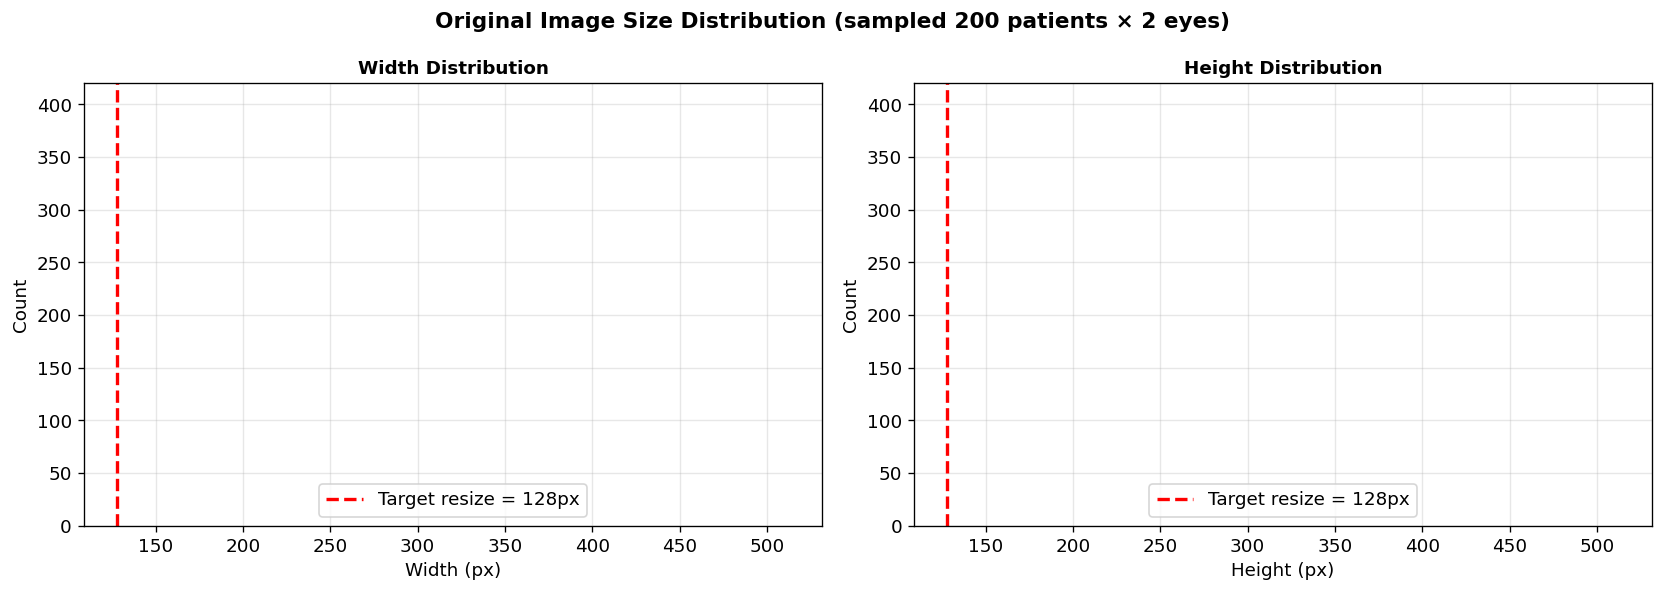

Width  — min:512, max:512, mean:512
Height — min:512, max:512, mean:512


In [12]:
# Sample 200 images to check original sizes
N_SAMPLE = 200
widths, heights = [], []

sampled = df.sample(n=min(N_SAMPLE, len(df)), random_state=42)
for _, row in sampled.iterrows():
    for side in ['left', 'right']:
        path = os.path.join(IMAGE_DIR, f"{row['ID']}_{side}.jpg")
        try:
            w, h = Image.open(path).size
            widths.append(w)
            heights.append(h)
        except Exception:
            pass

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f'Original Image Size Distribution (sampled {N_SAMPLE} patients × 2 eyes)',
             fontsize=13, fontweight='bold')

axes[0].hist(widths, bins=30, color='#4C72B0', edgecolor='white', alpha=0.85)
axes[0].axvline(IMAGE_SIZE, color='red', linestyle='--', linewidth=2,
                label=f'Target resize = {IMAGE_SIZE}px')
axes[0].set_title('Width Distribution', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Width (px)')
axes[0].set_ylabel('Count')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].hist(heights, bins=30, color='#55A868', edgecolor='white', alpha=0.85)
axes[1].axvline(IMAGE_SIZE, color='red', linestyle='--', linewidth=2,
                label=f'Target resize = {IMAGE_SIZE}px')
axes[1].set_title('Height Distribution', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Height (px)')
axes[1].set_ylabel('Count')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('chart_image_sizes.png', bbox_inches='tight')
plt.show()
print(f"Width  — min:{min(widths)}, max:{max(widths)}, mean:{np.mean(widths):.0f}")
print(f"Height — min:{min(heights)}, max:{max(heights)}, mean:{np.mean(heights):.0f}")

---
## Summary

| Chart | Saved File |
|---|---|
| Label distribution | `chart_label_distribution.png` |
| Patient demographics | `chart_demographics.png` |
| Multi-label & co-occurrence | `chart_multilabel.png` |
| Train/Val/Test split | `chart_split.png` |
| Sample images per class | `chart_sample_images.png` |
| Preprocessing pipeline | `chart_preprocess_pipeline.png` |
| Normalization effect | `chart_normalization.png` |
| Pixel / RGB statistics | `chart_pixel_stats.png` |
| Image size distribution | `chart_image_sizes.png` |